In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

In [2]:
file_name = "NYC_Building_Energy_and_Water_Data_Disclosure_shared_cleaned.csv"
df = pd.read_csv(file_name, low_memory=False)
print("Shape:", df.shape)
print("Number of columns:", len(df.columns))
df.head()

Shape: (103259, 265)
Number of columns: 265


,Calendar Year,Property ID,Property Name,Parent Property ID,Parent Property Name,Year Ending,"NYC Borough, Block and Lot (BBL)",NYC Building Identification Number (BIN),Address 1,City,...,Aggregate Meter(s)-District Steam – Number of Individual Meters Included,Report Generation Date,Report Submission Date,Borough,Latitude,Longitude,Community Board,Council District,Census Tract (2020),Neighborhood Tabulation Area (NTA) (2020)
0,2022,6414946,58-01 Grand Avenue,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2022,4026780001,4059918,58-01 Grand Avenue,Queens,...,NaN,04/25/2023 11:01:00 AM,04/25/2023 11:02:00 AM,QUEENS,40.719667,-73.911197,405.0,30.0,531.0,QN0501
1,2022,9793770,1870 Pelham Parkway South,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2022,2042500026,2047795,1870 Pelham Parkway South,Bronx,...,NaN,03/11/2023 02:00:00 PM,03/11/2023 02:01:00 PM,BRONX,40.855488,-73.830726,210.0,13.0,300.0,BX1003
2,2022,10177418,Central Building,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2022,4157040040,4300145,2011 Mott Ave,Far Rockaway,...,NaN,04/14/2023 03:47:00 PM,04/14/2023 03:47:00 PM,QUEENS,40.604320,-73.753009,414.0,31.0,100803.0,QN1401
3,2022,13511507,215 East 99th Street,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2022,1016490009,1052383,215 East 99th Street,New York,...,NaN,03/12/2023 03:54:00 PM,03/12/2023 03:54:00 PM,MANHATTAN,40.786963,-73.947537,111.0,8.0,164.0,MN1101
4,2022,14009907,23-25 31 Street,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2022,4008350027,4017180,23-25 31 Street,Queens,...,NaN,04/28/2023 02:22:00 PM,04/28/2023 02:23:00 PM,QUEENS,40.773768,-73.913573,401.0,22.0,115.0,QN0101


In [3]:
col_year = "Calendar Year"
col_energy = "Weather Normalized Site EUI (kBtu/ft²)"
col_water = "Water Use (All Water Sources) (kgal)"
col_gfa = "Property GFA - Calculated (Buildings and Parking) (ft²)"
col_type = "Primary Property Type - Self Selected"
col_yb = "Year Built"

target_year = 2024

In [4]:
def coerce_numeric(series):
    s = series.astype(str).str.strip()
    s = s.replace({
        "": np.nan,
        "nan": np.nan,
        "None": np.nan,
        "Not Available": np.nan
    })
    s = s.str.replace(",", "", regex=False)
    s = s.str.replace(r"[^0-9.\-]", "", regex=True)
    return pd.to_numeric(s, errors="coerce")


def winsorize(series, lower_q=0.01, upper_q=0.99):
    lower = series.quantile(lower_q)
    upper = series.quantile(upper_q)
    return series.clip(lower, upper)

In [5]:
for col in [col_year, col_energy, col_water, col_gfa, col_yb]:
    df[col] = coerce_numeric(df[col])

print("Numeric conversion complete.")

Numeric conversion complete.


In [6]:
df_2024 = df[df[col_year] == target_year].copy()

print("Records in 2024:", len(df_2024))
df_2024.head()

Records in 2024: 39090


,Calendar Year,Property ID,Property Name,Parent Property ID,Parent Property Name,Year Ending,"NYC Borough, Block and Lot (BBL)",NYC Building Identification Number (BIN),Address 1,City,...,Aggregate Meter(s)-District Steam – Number of Individual Meters Included,Report Generation Date,Report Submission Date,Borough,Latitude,Longitude,Community Board,Council District,Census Tract (2020),Neighborhood Tabulation Area (NTA) (2020)
4823,2024,53687992,Turkish House,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2024,1013380030,1090642,821 1st Ave.,New York,...,0.0,08/30/2025 12:00:00 AM,NaN,MANHATTAN,40.751281,-73.968051,106.0,4.0,90.0,MN0604
6782,2024,54411292,Dongan Tower Condominium 1 LLC,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2024,4015407502,4617249,81-05 Queens Boulevard,Queens,...,0.0,08/30/2025 12:00:00 AM,NaN,QUEENS,40.737798,-73.882717,404.0,25.0,485.0,QN0401
13259,2024,66074492,RY - Yorkville Towers - PARENT,66074492,RY - Yorkville Towers - PARENT,12/31/2024,1015377501;1015367501,1086170;1086171;1086172,1601 Third Avenue / 1635 Third Avenue,New York,...,0.0,08/30/2025 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22241,2024,2654832,Milstein - 200-210 East 65th Street,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2024,1014197502,1076307,200-210 East 65th Street,New York,...,0.0,08/30/2025 12:00:00 AM,NaN,MANHATTAN,40.765162,-73.963514,108.0,5.0,118.0,MN0801
39145,2024,3111942,Astor Condominiums,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2024,4006137501,4008368,31 - 35 31st St,Astoria,...,0.0,08/30/2025 12:00:00 AM,NaN,QUEENS,40.763954,-73.923766,401.0,22.0,61.0,QN0103


In [7]:
missing_summary = pd.DataFrame({
    "missing_count": df_2024[[col_energy, col_water, col_gfa, col_type, col_yb]].isna().sum(),
    "missing_rate": df_2024[[col_energy, col_water, col_gfa, col_type, col_yb]].isna().mean()
}).sort_values("missing_rate", ascending=False)

display(missing_summary)

,missing_count,missing_rate
Water Use (All Water Sources) (kgal),20470,0.523663
Weather Normalized Site EUI (kBtu/ft²),9757,0.249603
Property GFA - Calculated (Buildings and Parking) (ft²),35,0.000895
Primary Property Type - Self Selected,0,0.000000
Year Built,0,0.000000


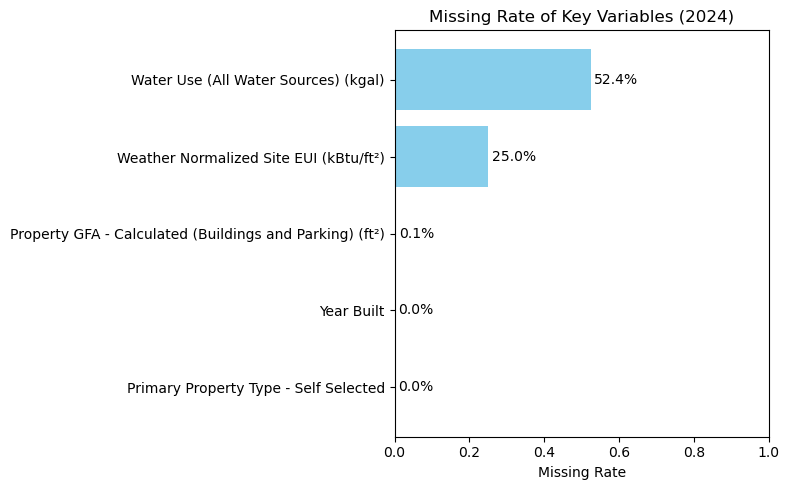

In [8]:
plot_df = missing_summary["missing_rate"].sort_values()

plt.figure(figsize=(8, 5))
bars = plt.barh(plot_df.index, plot_df.values, color="skyblue")
plt.xlabel("Missing Rate")
plt.title("Missing Rate of Key Variables (2024)")
plt.xlim(0, 1)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height() / 2, f"{width:.1%}", va="center")

plt.tight_layout()
plt.show()

In [9]:
work = df_2024.copy()

work = work[
    (work[col_gfa] > 0) &
    (work[col_energy] > 0) &
    (work[col_water] > 0)
].copy()

work["water_intensity"] = work[col_water] / work[col_gfa]
work = work[work["water_intensity"] > 0].copy()

print("Records after filtering:", len(work))
print("Retention rate:", round(len(work) / len(df_2024) * 100, 2), "%")

Records after filtering: 17215
Retention rate: 44.04 %


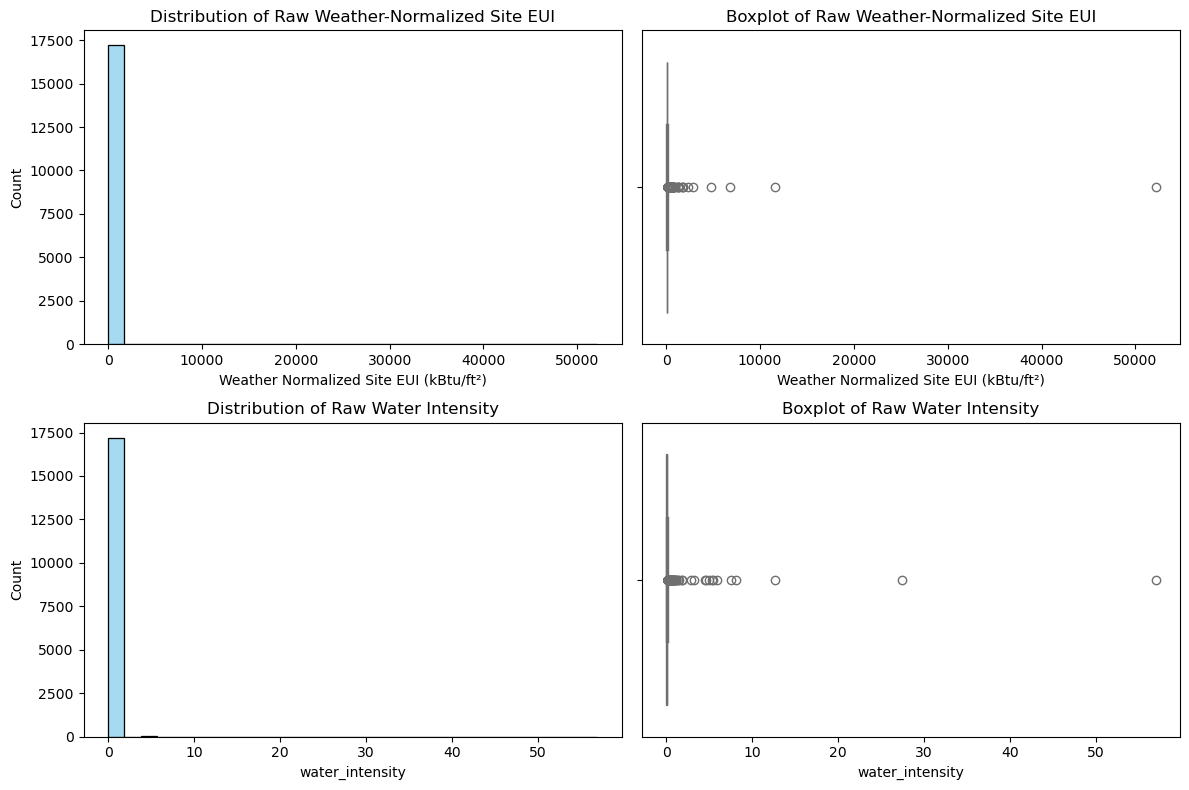

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(work[col_energy].dropna(), bins=30, color="skyblue", ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Raw Weather-Normalized Site EUI")

sns.boxplot(x=work[col_energy].dropna(), color="skyblue", ax=axes[0, 1])
axes[0, 1].set_title("Boxplot of Raw Weather-Normalized Site EUI")

sns.histplot(work["water_intensity"].dropna(), bins=30, color="skyblue", ax=axes[1, 0])
axes[1, 0].set_title("Distribution of Raw Water Intensity")

sns.boxplot(x=work["water_intensity"].dropna(), color="skyblue", ax=axes[1, 1])
axes[1, 1].set_title("Boxplot of Raw Water Intensity")

plt.tight_layout()
plt.show()

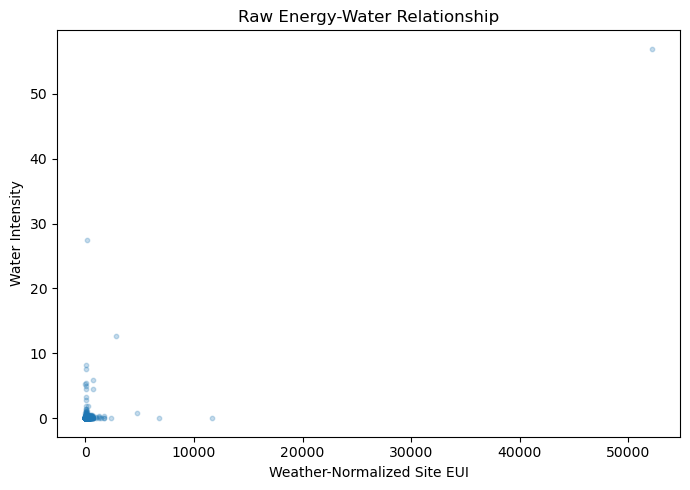

In [11]:
plt.figure(figsize=(7, 5))
plt.scatter(work[col_energy], work["water_intensity"], alpha=0.25, s=10)
plt.xlabel("Weather-Normalized Site EUI")
plt.ylabel("Water Intensity")
plt.title("Raw Energy-Water Relationship")
plt.tight_layout()
plt.show()

In [12]:
work["energy_wins"] = winsorize(work[col_energy], 0.01, 0.99)
work["water_intensity_wins"] = winsorize(work["water_intensity"], 0.01, 0.99)
work["log_water_intensity"] = np.log1p(work["water_intensity_wins"])

work["property_type_clean"] = work[col_type].fillna("Unknown").astype(str)

work["size_bin"] = pd.qcut(
    work[col_gfa],
    q=4,
    labels=["Small", "Medium", "Large", "Very Large"],
    duplicates="drop"
)

work["vintage_bin"] = pd.cut(
    work[col_yb],
    bins=[-np.inf, 1939, 1979, 1999, np.inf],
    labels=["Pre-1940", "1940-1979", "1980-1999", "2000 and later"],
    include_lowest=True
)

work.head()

,Calendar Year,Property ID,Property Name,Parent Property ID,Parent Property Name,Year Ending,"NYC Borough, Block and Lot (BBL)",NYC Building Identification Number (BIN),Address 1,City,...,Council District,Census Tract (2020),Neighborhood Tabulation Area (NTA) (2020),water_intensity,energy_wins,water_intensity_wins,log_water_intensity,property_type_clean,size_bin,vintage_bin
4823,2024,53687992,Turkish House,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2024,1013380030,1090642,821 1st Ave.,New York,...,4.0,90.0,MN0604,0.014532,122.8,0.014532,0.014428,Mixed Use Property,Very Large,2000 and later
6782,2024,54411292,Dongan Tower Condominium 1 LLC,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2024,4015407502,4617249,81-05 Queens Boulevard,Queens,...,25.0,485.0,QN0401,0.023112,35.4,0.023112,0.022849,Multifamily Housing,Large,2000 and later
22241,2024,2654832,Milstein - 200-210 East 65th Street,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2024,1014197502,1076307,200-210 East 65th Street,New York,...,5.0,118.0,MN0801,0.032641,114.9,0.032641,0.032120,Multifamily Housing,Very Large,1980-1999
39145,2024,3111942,Astor Condominiums,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2024,4006137501,4008368,31 - 35 31st St,Astoria,...,22.0,61.0,QN0103,0.022607,45.9,0.022607,0.022355,Multifamily Housing,Large,2000 and later
39464,2024,2660223,Wallack - 10 East End Ave,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2024,1015760027,1050768,10 EAST END AVENUE,New York,...,5.0,13602.0,MN0803,0.032127,60.5,0.032127,0.031622,Multifamily Housing,Very Large,1940-1979


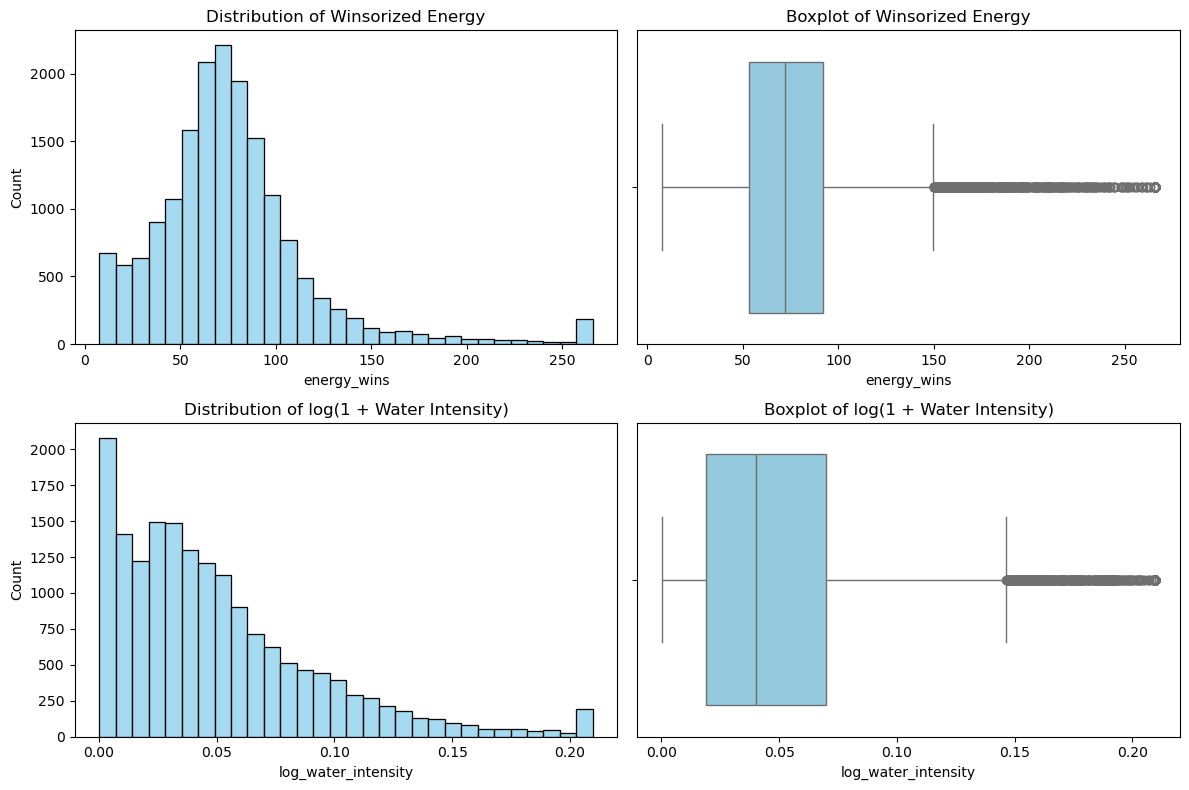

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(work["energy_wins"], bins=30, color="skyblue", ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Winsorized Energy")

sns.boxplot(x=work["energy_wins"], color="skyblue", ax=axes[0, 1])
axes[0, 1].set_title("Boxplot of Winsorized Energy")

sns.histplot(work["log_water_intensity"], bins=30, color="skyblue", ax=axes[1, 0])
axes[1, 0].set_title("Distribution of log(1 + Water Intensity)")

sns.boxplot(x=work["log_water_intensity"], color="skyblue", ax=axes[1, 1])
axes[1, 1].set_title("Boxplot of log(1 + Water Intensity)")

plt.tight_layout()
plt.show()

In [14]:
feature_df = work[["energy_wins", "log_water_intensity"]].dropna().copy()
work = work.loc[feature_df.index].copy()

scaler = StandardScaler()
X = scaler.fit_transform(feature_df)

print("Final clustering sample size:", len(work))

Final clustering sample size: 17215


In [15]:
seeds = [7, 11, 21, 42, 88]
results = []

for k in range(2, 11):
    inertias = []
    silhouettes = []
    labels_by_seed = {}

    for seed in seeds:
        km = KMeans(n_clusters=k, random_state=seed, n_init=20)
        labels = km.fit_predict(X)

        inertias.append(km.inertia_)
        silhouettes.append(
            silhouette_score(X, labels, sample_size=2000, random_state=seed)
        )
        labels_by_seed[seed] = labels

    aris = []
    seed_list = list(labels_by_seed.keys())
    for i in range(len(seed_list)):
        for j in range(i + 1, len(seed_list)):
            aris.append(
                adjusted_rand_score(labels_by_seed[seed_list[i]], labels_by_seed[seed_list[j]])
            )

    results.append({
        "k": k,
        "inertia_mean": np.mean(inertias),
        "silhouette_mean": np.mean(silhouettes),
        "stability_mean_ari": np.mean(aris)
    })

results_df = pd.DataFrame(results)
display(results_df)

,k,inertia_mean,silhouette_mean,stability_mean_ari
0,2,19813.504361,0.469081,0.993352
1,3,14621.661015,0.461931,0.995162
2,4,11000.121552,0.354998,0.986709
3,5,9186.412468,0.333234,0.959138
4,6,7893.485331,0.336101,0.981119
5,7,6929.400980,0.326489,0.979942
6,8,6071.902074,0.340064,0.952806
7,9,5312.073402,0.346592,0.990405
8,10,4798.813801,0.336613,0.966064


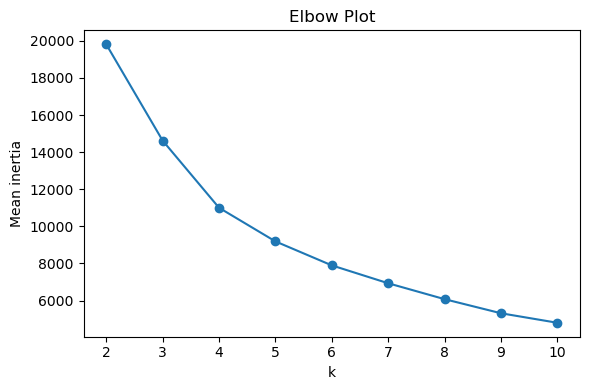

In [16]:
plt.figure(figsize=(6, 4))
plt.plot(results_df["k"], results_df["inertia_mean"], marker="o")
plt.xlabel("k")
plt.ylabel("Mean inertia")
plt.title("Elbow Plot")
plt.tight_layout()
plt.show()

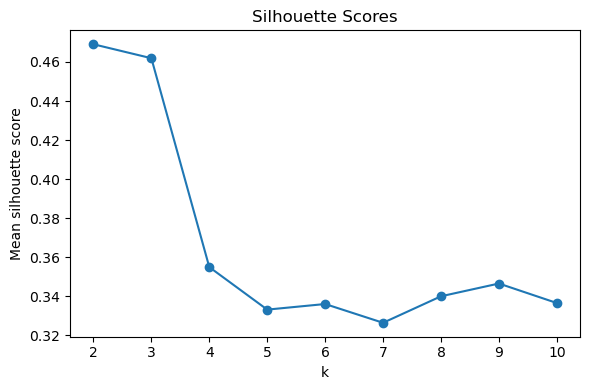

In [17]:
plt.figure(figsize=(6, 4))
plt.plot(results_df["k"], results_df["silhouette_mean"], marker="o")
plt.xlabel("k")
plt.ylabel("Mean silhouette score")
plt.title("Silhouette Scores")
plt.tight_layout()
plt.show()

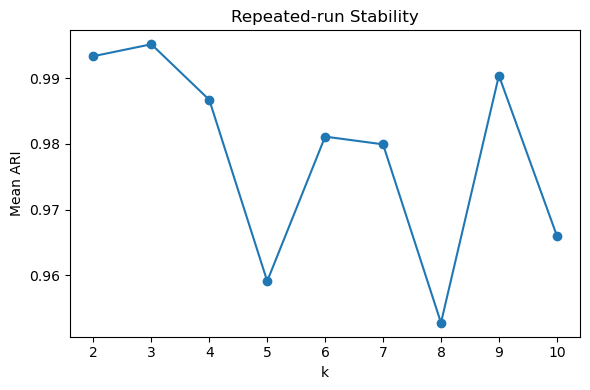

In [18]:
plt.figure(figsize=(6, 4))
plt.plot(results_df["k"], results_df["stability_mean_ari"], marker="o")
plt.xlabel("k")
plt.ylabel("Mean ARI")
plt.title("Repeated-run Stability")
plt.tight_layout()
plt.show()

In [19]:
final_k = 3
print("Selected final k =", final_k)

Selected final k = 3


In [20]:
final_km = KMeans(n_clusters=final_k, random_state=42, n_init=20)
work["cluster"] = final_km.fit_predict(X)

display(work["cluster"].value_counts().sort_index())

cluster
0     4480
1    11858
2      877
Name: count, dtype: int64

In [21]:
centers_original = scaler.inverse_transform(final_km.cluster_centers_)

centers_df = pd.DataFrame(
    centers_original,
    columns=["energy_wins_center", "log_water_center"]
)
centers_df["cluster"] = centers_df.index
centers_df["approx_water_intensity_center"] = np.expm1(centers_df["log_water_center"])

display(centers_df)

,energy_wins_center,log_water_center,cluster,approx_water_intensity_center
0,91.577316,0.102796,0,0.108266
1,61.735695,0.029012,1,0.029436
2,197.859117,0.067232,2,0.069543


In [22]:
cluster_summary = (
    work.groupby("cluster")
    .agg(
        n=("cluster", "size"),
        energy_mean=("energy_wins", "mean"),
        energy_median=("energy_wins", "median"),
        water_mean=("water_intensity_wins", "mean"),
        water_median=("water_intensity_wins", "median"),
        gfa_median=(col_gfa, "median")
    )
    .reset_index()
)

cluster_summary = cluster_summary.merge(centers_df, on="cluster", how="left")
display(cluster_summary)

,cluster,n,energy_mean,energy_median,water_mean,water_median,gfa_median,energy_wins_center,log_water_center,approx_water_intensity_center
0,0,4480,91.547181,91.75,0.109099,0.099177,48820.0,91.577316,0.102796,0.108266
1,1,11858,61.749903,63.30,0.029643,0.028462,70336.5,61.735695,0.029012,0.029436
2,2,877,197.661537,187.20,0.071238,0.055528,57050.0,197.859117,0.067232,0.069543


In [23]:
cluster_names = {
    0: "Moderate Energy - Higher Water",
    1: "Low Energy - Low Water",
    2: "High Energy - Moderate Water"
}

work["cluster_name"] = work["cluster"].map(cluster_names)
cluster_summary["cluster_name"] = cluster_summary["cluster"].map(cluster_names)

display(cluster_summary)

,cluster,n,energy_mean,energy_median,water_mean,water_median,gfa_median,energy_wins_center,log_water_center,approx_water_intensity_center,cluster_name
0,0,4480,91.547181,91.75,0.109099,0.099177,48820.0,91.577316,0.102796,0.108266,Moderate Energy - Higher Water
1,1,11858,61.749903,63.30,0.029643,0.028462,70336.5,61.735695,0.029012,0.029436,Low Energy - Low Water
2,2,877,197.661537,187.20,0.071238,0.055528,57050.0,197.859117,0.067232,0.069543,High Energy - Moderate Water


In [24]:
cluster_names = {
    0: "Moderate Energy - Higher Water",
    1: "Low Energy - Low Water",
    2: "High Energy - Moderate Water"
}

work["cluster_name"] = work["cluster"].map(cluster_names)
cluster_summary["cluster_name"] = cluster_summary["cluster"].map(cluster_names)

cluster_summary

,cluster,n,energy_mean,energy_median,water_mean,water_median,gfa_median,energy_wins_center,log_water_center,approx_water_intensity_center,cluster_name
0,0,4480,91.547181,91.75,0.109099,0.099177,48820.0,91.577316,0.102796,0.108266,Moderate Energy - Higher Water
1,1,11858,61.749903,63.30,0.029643,0.028462,70336.5,61.735695,0.029012,0.029436,Low Energy - Low Water
2,2,877,197.661537,187.20,0.071238,0.055528,57050.0,197.859117,0.067232,0.069543,High Energy - Moderate Water


### Save the final clustering artifact for quick demo

The final KMeans artifact is saved together with the scaler and preprocessing thresholds so cluster assignment can be reproduced consistently for a quick demo.


In [26]:
import joblib
from pathlib import Path

energy_lower = work[col_energy].quantile(0.01)
energy_upper = work[col_energy].quantile(0.99)
water_lower = work["water_intensity"].quantile(0.01)
water_upper = work["water_intensity"].quantile(0.99)

cluster_artifact = {
    "model": final_km,
    "scaler": scaler,
    "final_k": final_k,
    "energy_lower": energy_lower,
    "energy_upper": energy_upper,
    "water_lower": water_lower,
    "water_upper": water_upper,
    "feature_names": ["energy_wins", "log_water_intensity"],
    "cluster_names": cluster_names,
}

model_path = "chao_kmeans_cluster_artifact.pkl"
joblib.dump(cluster_artifact, model_path, compress=3)

loaded_artifact = joblib.load(model_path)
size_mb = Path(model_path).stat().st_size / (1024 * 1024)

sample_row = work.iloc[[0]].copy()
sample_energy = sample_row[col_energy].clip(lower=energy_lower, upper=energy_upper)
sample_water_intensity = (sample_row[col_water] / sample_row[col_gfa]).clip(lower=water_lower, upper=water_upper)
sample_log_water = np.log1p(sample_water_intensity)

sample_features = pd.DataFrame({
    "energy_wins": sample_energy.values,
    "log_water_intensity": sample_log_water.values
})

sample_scaled = loaded_artifact["scaler"].transform(sample_features)
sample_cluster = loaded_artifact["model"].predict(sample_scaled)[0]

print("Reload success:", type(loaded_artifact))
print(f"File size: {size_mb:.2f} MB")
print("Saved keys:", list(loaded_artifact.keys()))
print("Demo cluster assignment:", sample_cluster)
print("Cluster name:", loaded_artifact["cluster_names"].get(sample_cluster, "Unknown"))


Reload success: <class 'dict'>
File size: 0.01 MB
Saved keys: ['model', 'scaler', 'final_k', 'energy_lower', 'energy_upper', 'water_lower', 'water_upper', 'feature_names', 'cluster_names']
Demo cluster assignment: 1
Cluster name: Low Energy - Low Water


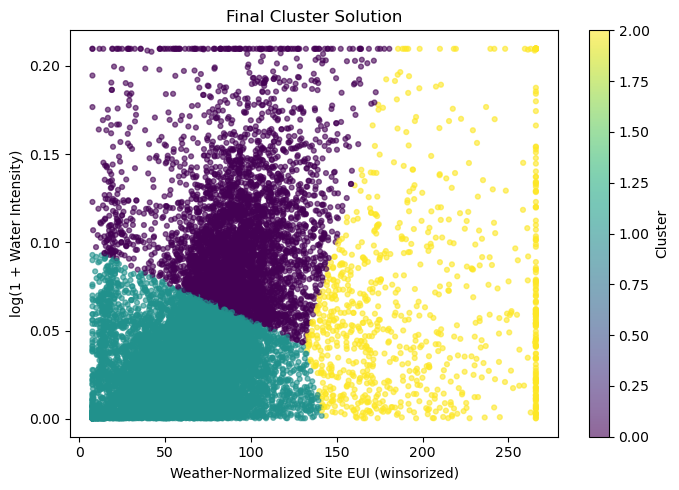

In [27]:
plt.figure(figsize=(7, 5))
sc = plt.scatter(
    work["energy_wins"],
    work["log_water_intensity"],
    c=work["cluster"],
    s=12,
    alpha=0.6
)
plt.xlabel("Weather-Normalized Site EUI (winsorized)")
plt.ylabel("log(1 + Water Intensity)")
plt.title("Final Cluster Solution")
plt.colorbar(sc, label="Cluster")
plt.tight_layout()
plt.show()

In [28]:
cluster_by_type_counts = pd.crosstab(work["cluster_name"], work["property_type_clean"])
cluster_by_type_percent = (
    pd.crosstab(work["cluster_name"], work["property_type_clean"], normalize="index") * 100
).round(2)

display(cluster_by_type_counts)
display(cluster_by_type_percent)

property_type_clean,Adult Education,Ambulatory Surgical Center,Bank Branch,Bowling Alley,College/University,Community Center and Social Meeting Hall,Convention Center,Courthouse,Data Center,Distribution Center,...,Transportation Terminal/Station,Urgent Care/Clinic/Other Outpatient,Vehicle Dealership,Vehicle Repair Services,Veterinary Office,Vocational School,Wastewater Treatment Plant,Wholesale Club/Supercenter,Worship Facility,Zoo
cluster_name,,,,,,,,,,,,,,,,,,,,,
High Energy - Moderate Water,0,1,0,0,7,4,0,2,49,0,...,4,6,0,22,1,1,10,0,2,2
Low Energy - Low Water,4,5,7,10,82,20,0,12,5,109,...,3,17,14,39,1,4,0,12,100,0
Moderate Energy - Higher Water,0,0,0,0,1,4,1,0,4,0,...,0,0,0,0,0,0,1,1,5,0


property_type_clean,Adult Education,Ambulatory Surgical Center,Bank Branch,Bowling Alley,College/University,Community Center and Social Meeting Hall,Convention Center,Courthouse,Data Center,Distribution Center,...,Transportation Terminal/Station,Urgent Care/Clinic/Other Outpatient,Vehicle Dealership,Vehicle Repair Services,Veterinary Office,Vocational School,Wastewater Treatment Plant,Wholesale Club/Supercenter,Worship Facility,Zoo
cluster_name,,,,,,,,,,,,,,,,,,,,,
High Energy - Moderate Water,0.00,0.11,0.00,0.00,0.80,0.46,0.00,0.23,5.59,0.00,...,0.46,0.68,0.00,2.51,0.11,0.11,1.14,0.00,0.23,0.23
Low Energy - Low Water,0.03,0.04,0.06,0.08,0.69,0.17,0.00,0.10,0.04,0.92,...,0.03,0.14,0.12,0.33,0.01,0.03,0.00,0.10,0.84,0.00
Moderate Energy - Higher Water,0.00,0.00,0.00,0.00,0.02,0.09,0.02,0.00,0.09,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.02,0.11,0.00


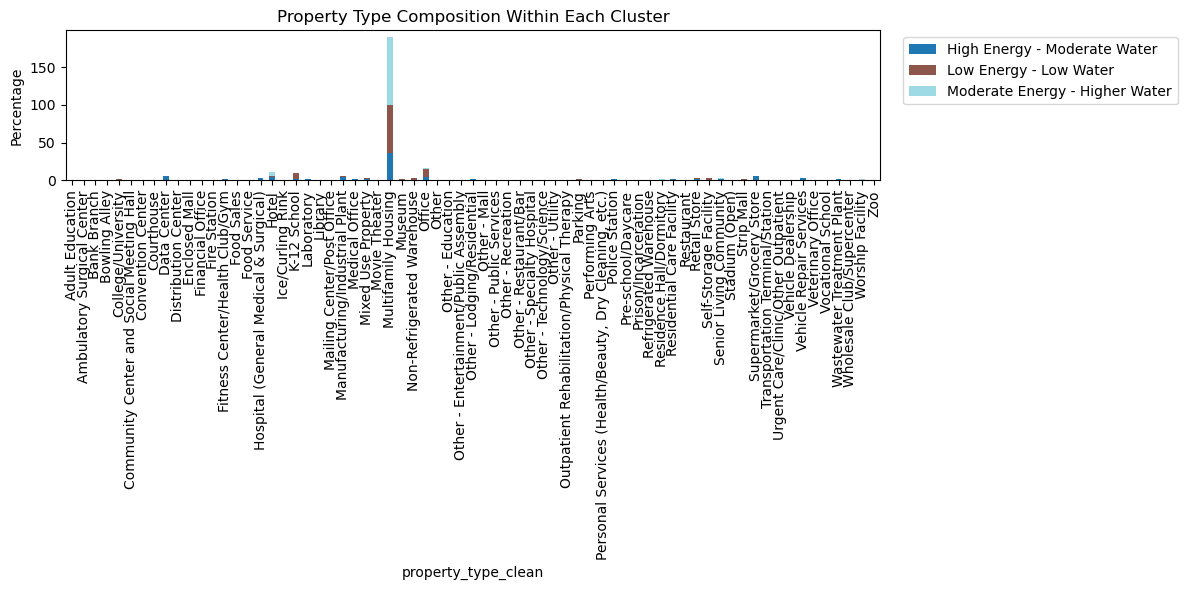

In [29]:
cluster_by_type_percent.T.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="tab20"
)
plt.ylabel("Percentage")
plt.title("Property Type Composition Within Each Cluster")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [31]:
cluster_by_size_counts = pd.crosstab(work["cluster_name"], work["size_bin"])
cluster_by_size_percent = (
    pd.crosstab(work["cluster_name"], work["size_bin"], normalize="index") * 100
).round(2)

display(cluster_by_size_counts)
display(cluster_by_size_percent)

size_bin,Small,Medium,Large,Very Large
cluster_name,,,,
High Energy - Moderate Water,289,182,167,239
Low Energy - Low Water,2520,2654,3105,3579
Moderate Energy - Higher Water,1495,1468,1038,479


size_bin,Small,Medium,Large,Very Large
cluster_name,,,,
High Energy - Moderate Water,32.95,20.75,19.04,27.25
Low Energy - Low Water,21.25,22.38,26.18,30.18
Moderate Energy - Higher Water,33.37,32.77,23.17,10.69


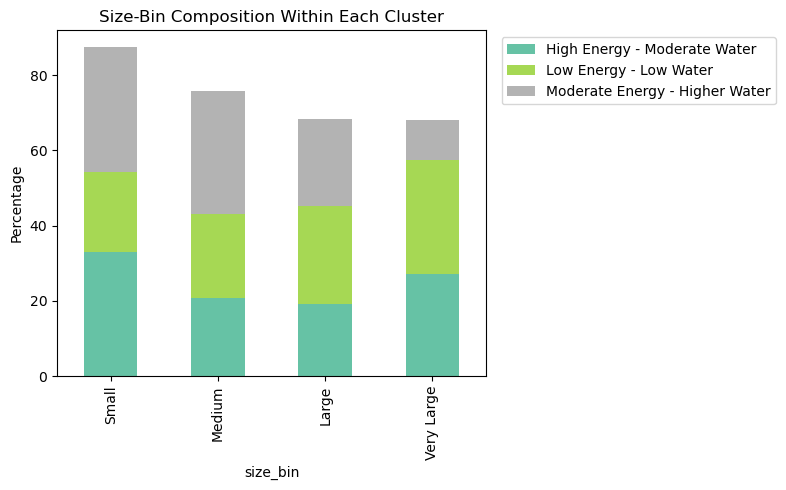

In [32]:
cluster_by_size_percent.T.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    colormap="Set2"
)
plt.ylabel("Percentage")
plt.title("Size-Bin Composition Within Each Cluster")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [33]:
cluster_by_vintage_counts = pd.crosstab(work["cluster_name"], work["vintage_bin"])
cluster_by_vintage_percent = (
    pd.crosstab(work["cluster_name"], work["vintage_bin"], normalize="index") * 100
).round(2)

display(cluster_by_vintage_counts)
display(cluster_by_vintage_percent)

vintage_bin,Pre-1940,1940-1979,1980-1999,2000 and later
cluster_name,,,,
High Energy - Moderate Water,388,320,60,109
Low Energy - Low Water,5201,3191,861,2605
Moderate Energy - Higher Water,2877,921,219,463


vintage_bin,Pre-1940,1940-1979,1980-1999,2000 and later
cluster_name,,,,
High Energy - Moderate Water,44.24,36.49,6.84,12.43
Low Energy - Low Water,43.86,26.91,7.26,21.97
Moderate Energy - Higher Water,64.22,20.56,4.89,10.33


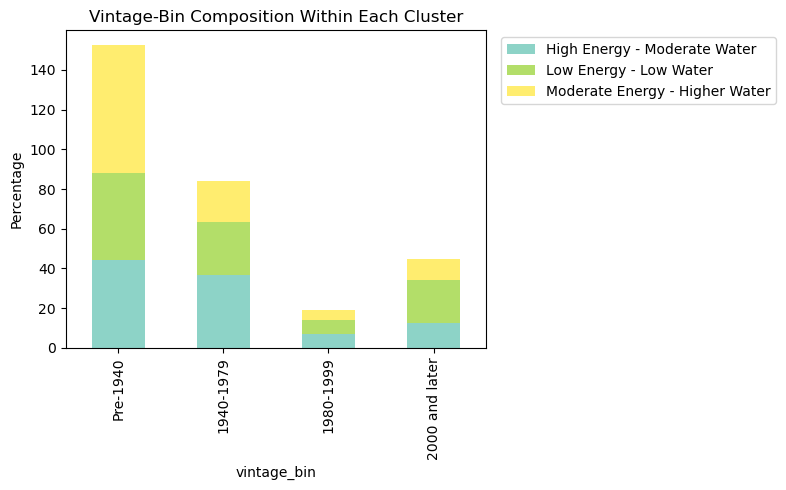

In [34]:
cluster_by_vintage_percent.T.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    colormap="Set3"
)
plt.ylabel("Percentage")
plt.title("Vintage-Bin Composition Within Each Cluster")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [35]:
print("Summary:")
print("- Target year:", target_year)
print("- Records in 2024:", len(df_2024))
print("- Records after filtering:", len(work))
print("- Final number of clusters:", final_k)
print("\nCluster summary:")
display(cluster_summary)

Summary:
- Target year: 2024
- Records in 2024: 39090
- Records after filtering: 17215
- Final number of clusters: 3

Cluster summary:


,cluster,n,energy_mean,energy_median,water_mean,water_median,gfa_median,energy_wins_center,log_water_center,approx_water_intensity_center,cluster_name
0,0,4480,91.547181,91.75,0.109099,0.099177,48820.0,91.577316,0.102796,0.108266,Moderate Energy - Higher Water
1,1,11858,61.749903,63.30,0.029643,0.028462,70336.5,61.735695,0.029012,0.029436,Low Energy - Low Water
2,2,877,197.661537,187.20,0.071238,0.055528,57050.0,197.859117,0.067232,0.069543,High Energy - Moderate Water
